<a href="https://colab.research.google.com/github/malehzja/final-project/blob/main/final-project/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

# Task 2: Machine Learning
Build a machine learning model and choose the 'best' classifier for your dataset. Also, generate the classification report and confusion matrix.

## Install & Load Libraries

In [ ]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


## Load and Read .csv file from GitHub

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/final_lis4693/refs/heads/main/final-project/imdb_tvshows_sentiment.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

In [ ]:
import pandas as pd
df = pd.read_csv(io.StringIO(text), sep = ',')  # File is comma delimited
print(df.head())

   Unnamed: 0                                             Review  \
0           0  andor was every bit as good as i was hoping fo...   
1           1  wow. i just finished episode 12 of the first s...   
2           2  andor season 2 is the best star wars show ever...   
3           3  there were a few episodes i didn't like in bot...   
4           4  didnt like the new movies and even mandalorian...   

   sentiment_score  
0           0.9842  
1           0.9564  
2           0.9929  
3          -0.8118  
4           0.0382  


In [ ]:
# Create a column that classifies a review as positive (sentiment_score > 0.5) or negative (sentiment_score <= 0.5)
#df['sentiment_classifier'] = pd.cut(df['sentiment_score'], bins=[-1, 0.5, float('inf')], labels=[1, 0])
import numpy as np

# Define Conditions
conditions = [
    (df['sentiment_score'] <= 0.5),
    (df['sentiment_score'] > 0.5)
]

# Values for conditions
choices = ['0', '1']

# Apply conditions to create the new column
df['sentiment_classifier'] = np.select(conditions, choices, default='Unknown')

In [ ]:
print(df.head(10))

   Unnamed: 0                                             Review  \
0           0  andor was every bit as good as i was hoping fo...   
1           1  wow. i just finished episode 12 of the first s...   
2           2  andor season 2 is the best star wars show ever...   
3           3  there were a few episodes i didn't like in bot...   
4           4  didnt like the new movies and even mandalorian...   
5           5  i'll say it again: andor is one of the best pi...   
6           6  this is, minute for minute, some of the best t...   
7           7  andor is why i pay my disney+ subscription. th...   
8           8  i am going to put it plain and simple.  this s...   
9           9  this is the show anyone who grew up with class...   

   sentiment_score sentiment_classifier  
0           0.9842                    1  
1           0.9564                    1  
2           0.9929                    1  
3          -0.8118                    0  
4           0.0382                    0  

## Split data into **features** and **target** labels

In [ ]:
features = df['Review']
target = df['sentiment_classifier']

In [ ]:
target_names = {
    'negative' : '0',
    'positive' : '1'
              }

## Split Data into Training and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 6655 samples.
Testing set has 1664 samples.
Preprocessing training data...
Preprocessing test data...


In [ ]:
y_test.unique()

array(['1', '0'], dtype=object)

## Comparing Classifiers

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Adaboost classifier...
Training Random Forest classifier...


RandomForestClassifier()

In [ ]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [ ]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.7265625
SVM Accuracy: 0.8347355769230769
LR Accuracy: 0.8155048076923077
ADA Accuracy: 0.7584134615384616
RF Accuracy: 0.7433894230769231


### Since the SVM Accuracy score is the highest, it will be the classifier

In [ ]:
from sklearn.metrics import classification_report  # Import classification_report

print("Naive Bayes Classification Report ")
print(classification_report(y_test, nb_predictions, target_names=target_names))

print("\n Logistic Regression Classification Report ")
print(classification_report(y_test, lr_predictions, target_names=target_names))

print("\n AdaBoost Classification Report ")
print(classification_report(y_test, ada_predictions, target_names=target_names))

print("\n Random Forest Classification Report ")
print(classification_report(y_test, random_predictions, target_names=target_names))

Naive Bayes Classification Report 
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       455
    positive       0.73      1.00      0.84      1209

    accuracy                           0.73      1664
   macro avg       0.36      0.50      0.42      1664
weighted avg       0.53      0.73      0.61      1664


 Logistic Regression Classification Report 
              precision    recall  f1-score   support

    negative       0.80      0.43      0.56       455
    positive       0.82      0.96      0.88      1209

    accuracy                           0.82      1664
   macro avg       0.81      0.70      0.72      1664
weighted avg       0.81      0.82      0.80      1664


 AdaBoost Classification Report 
              precision    recall  f1-score   support

    negative       0.75      0.17      0.28       455
    positive       0.76      0.98      0.85      1209

    accuracy                           0.76      1664
   macro avg  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [ ]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [ ]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.8347355769230769


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

    negative       0.74      0.60      0.67       455
    positive       0.86      0.92      0.89      1209

    accuracy                           0.83      1664
   macro avg       0.80      0.76      0.78      1664
weighted avg       0.83      0.83      0.83      1664



(array([0.5, 1.5]), [Text(0.5, 0, 'negative'), Text(1.5, 0, 'positive')])

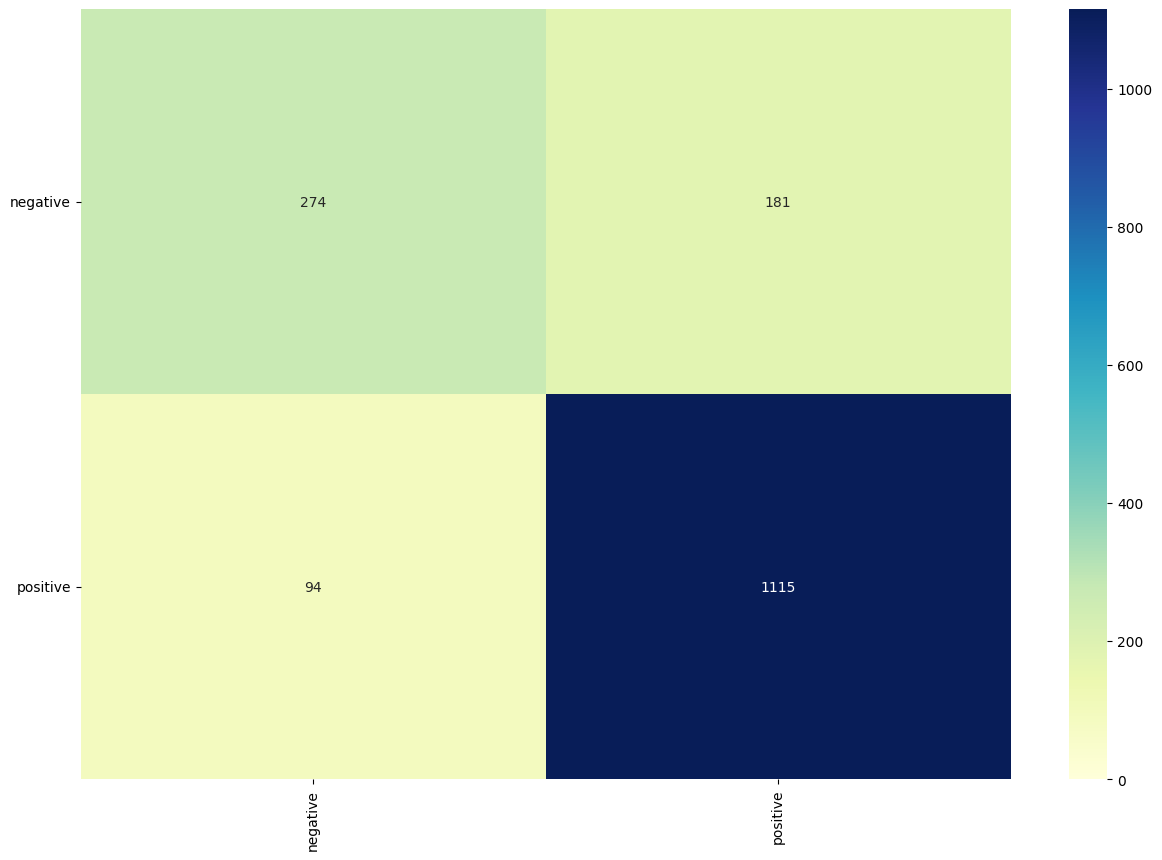

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, svm_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)